# Rule of Law K-Medoids Clean Pipeline
This notebook runs a compact end-to-end pipeline from data cleaning to cluster interpretation outputs with records of all the respondents.

## Step 0: Setup and Global Controls

In [22]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests
from sklearn.metrics import silhouette_score
from sklearn_extra.cluster import KMedoids

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

PATH_DATA = "OmnibusW1_November2025_UOFI.STAT427.xlsx"
K_CHOSEN = 3
MIN_DURATION_MIN = 2.0
UNKNOWN_CODE = 3
INTERACTION_ALPHA = 0.05
HEARD_FILTER_MODE = "yes"
APPLY_HEARD_FILTER = False

CONCEPT_COLS = [
    "NoOneAbove","Obey","Enforce","EveryoneObey","WayToFix",
    "Prospective","Clear","Consistent","Possible","Stable",
    "AsWritten","Knowable","SeparationPowers","RightsOfAccused",
    "AccessToLawyers","JudicialIndependence","AccessToCourts",
    "Respect","FairProcedures","Voice","NoProtest","Property",
    "WithoutCourt","CrimeControl","NoSelfDealing","EconGrowth",
    "Contracts","HumanRights","Majority","InnocentUntilProve",
    "TreatsEqual","DisputesInCourt","TrustAuthorities","Military",
    "RightToVote","WealthGap",
]

DEMO_VARS = [
    "SEX","AGE4","AGE7","RACETHNICITY","EDUC5","INCOME4","REGION4","REGION9","HHSIZE",
    "IDEO","PartyID5","PartyID7","HeardOf","NewsFreq","NEWSCONS","SURV_MODE","Device",
    "SURV_LANG","METRO","INTERNET"
]

assert os.path.exists(PATH_DATA), f"Data file not found: {PATH_DATA}"

## Step 1: Data Cleaning and Analysis Base
This step prepares concept variables, removes records at or below the duration threshold, and applies optional HeardOf filtering.

In [23]:
df = pd.read_excel(PATH_DATA)
CONCEPT_COLS = [c for c in CONCEPT_COLS if c in df.columns]
DEMO_VARS = [v for v in DEMO_VARS if v in df.columns]

X = (
    df[CONCEPT_COLS]
    .replace(["#NULL!"], np.nan)
    .apply(pd.to_numeric, errors="coerce")
    .replace({77: np.nan, 98: np.nan, 99: np.nan, -1: np.nan})
)

dur = pd.to_numeric(df["duration_UOFI"], errors="coerce")
keep_duration = dur > MIN_DURATION_MIN

meta = df.loc[keep_duration].copy()
X = X.loc[keep_duration].copy()
meta["duration_UOFI"] = dur.loc[keep_duration]
meta["WEIGHT_GP"] = pd.to_numeric(meta.get("WEIGHT_GP", 1.0), errors="coerce").fillna(1.0)

if APPLY_HEARD_FILTER and "HeardOf" in meta.columns:
    heard = pd.to_numeric(meta["HeardOf"], errors="coerce")
    if HEARD_FILTER_MODE == "yes":
        mask = heard.eq(1)
    elif HEARD_FILTER_MODE == "no":
        mask = heard.eq(2)
    else:
        mask = heard.notna()
    meta = meta.loc[mask].copy()
    X = X.loc[mask].copy()

print(f"Rows after duration filter (> {MIN_DURATION_MIN} min): {keep_duration.sum()}")
print(f"Rows in analysis set: {len(meta)}")

Rows after duration filter (> 2.0 min): 962
Rows in analysis set: 962


## Step 2: K-Medoids with Custom Gower-Style Distance
This step builds clusters using a DK-excluded pairwise distance matrix and assigns cluster labels for downstream analysis.

In [24]:
X_num = X.astype(float)
X_map = X_num.replace({1: 0.0, 2: 1.0, 4: 2.0, 5: 3.0, 3: np.nan})
A = X_map.to_numpy()

n, p = A.shape
D_sum = np.zeros((n, n), dtype=float)
W = np.zeros((n, n), dtype=float)

for k in range(p):
    col = A[:, k]
    idx = np.where(np.isfinite(col))[0]
    if idx.size < 2:
        continue
    v = col[idx]
    diff = np.abs(v[:, None] - v[None, :]) / 3.0
    D_sum[np.ix_(idx, idx)] += diff
    W[np.ix_(idx, idx)] += 1.0

D_custom = np.ones((n, n), dtype=float)
np.divide(D_sum, W, out=D_custom, where=W > 0)
np.fill_diagonal(D_custom, 0.0)

kmed = KMedoids(n_clusters=K_CHOSEN, metric="precomputed", init="k-medoids++", random_state=RANDOM_STATE)
clusters = kmed.fit_predict(D_custom)
meta = meta.copy()
meta["cluster_concept"] = clusters.astype(int)

sil = silhouette_score(D_custom, clusters, metric="precomputed")
print("Silhouette:", round(float(sil), 4))
print(meta["cluster_concept"].value_counts().sort_index())

Silhouette: 0.215
cluster_concept
0    309
1    526
2    127
Name: count, dtype: int64


/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/deprecation.py:95: FutureWarning: Function stable_cumsum is deprecated; `sklearn.utils.extmath.stable_cumsum` is deprecated in version 1.8 and will be removed in 1.10. Use `np.cumulative_sum` with the desired dtype directly instead.
  warnings.warn(msg, category=FutureWarning)


## Step 3: Demographics Screening, Profiling, and Multinomial Logit
This step screens demographics versus clusters and profiles significant variables, then fits the multinomial logit for cluster membership using HeardOf, all concept items, and HeardOf-by-item interactions with p-value-based interaction selection; predicted clusters feed Steps 4–5.

Interactions kept: 0 / 36 (p < 0.05, min p across outcome equations)
Demographic screen


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,var,chi2,df,p_value,cramers_v,p_fdr_bh
13,NewsFreq,85.952352,14,2.193969e-12,0.216832,4.168542e-11
12,HeardOf,53.246026,4,7.569087e-11,0.170663,7.190632e-10
5,INCOME4,42.826377,6,1.262442e-07,0.153056,7.995465e-07
14,NEWSCONS,99.681453,44,3.335671e-06,0.233508,1.584444e-05
4,EDUC5,32.327844,8,8.135165e-05,0.132979,3.091363e-04
11,PartyID7,37.453971,12,1.885160e-04,0.143134,5.969674e-04
16,Device,23.266700,6,7.119016e-04,0.112814,1.932304e-03
3,RACETHNICITY,29.544512,10,1.016554e-03,0.127126,2.414317e-03
0,SEX,12.775167,2,1.682317e-03,0.118221,3.551558e-03
10,PartyID5,24.512761,8,1.879157e-03,0.115795,3.570399e-03


Selected demographics (screening only): ['NewsFreq', 'HeardOf', 'INCOME4', 'NEWSCONS', 'EDUC5', 'PartyID7', 'Device', 'RACETHNICITY', 'SEX', 'PartyID5', 'REGION9', 'IDEO', 'AGE7', 'REGION4']
MNLogit in-sample accuracy (HeardOf + concepts + selected interactions): 0.866


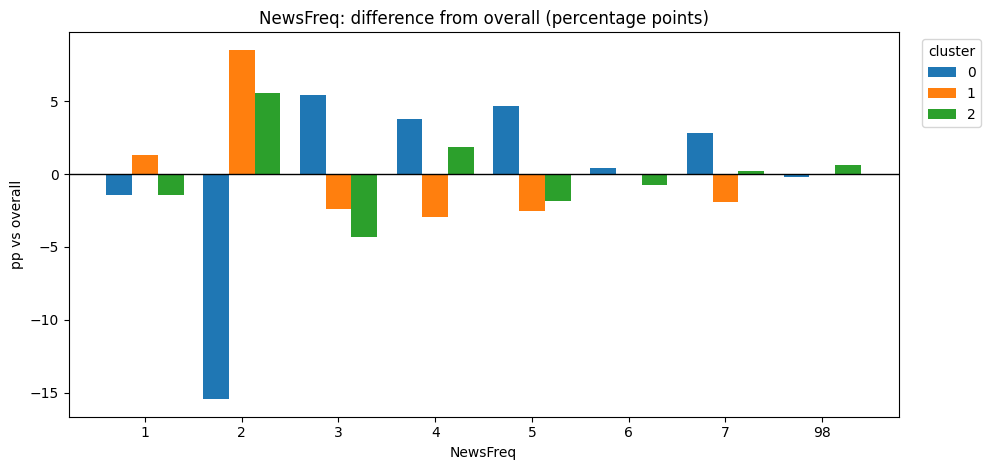

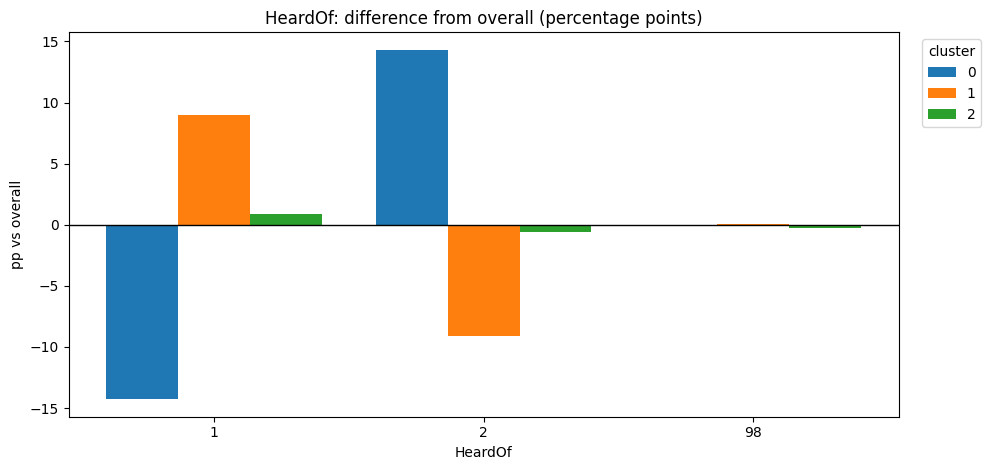

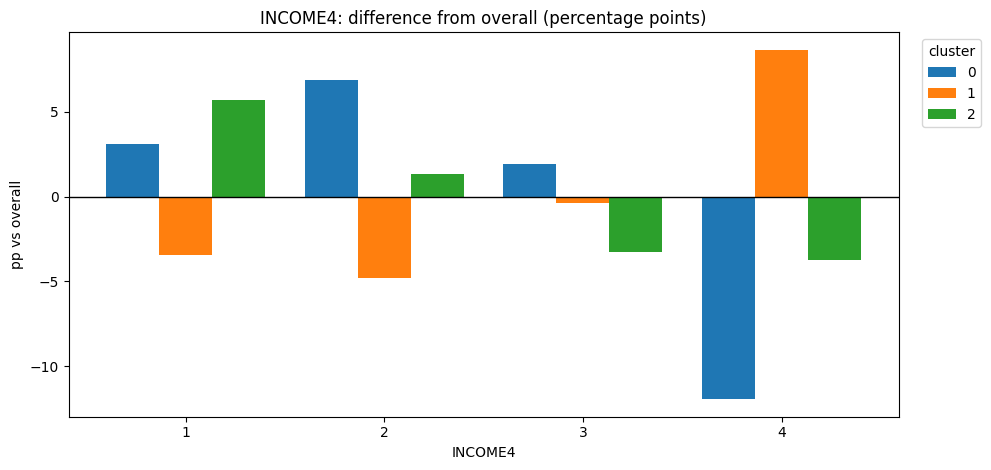

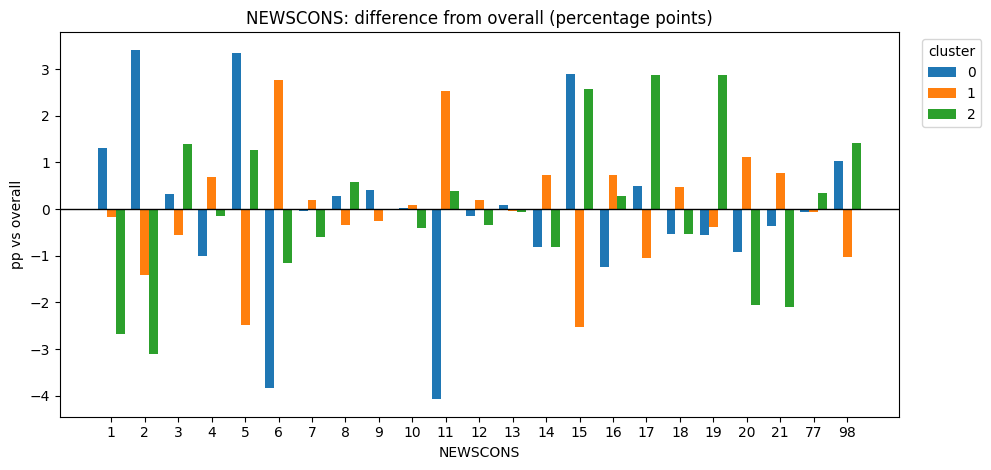

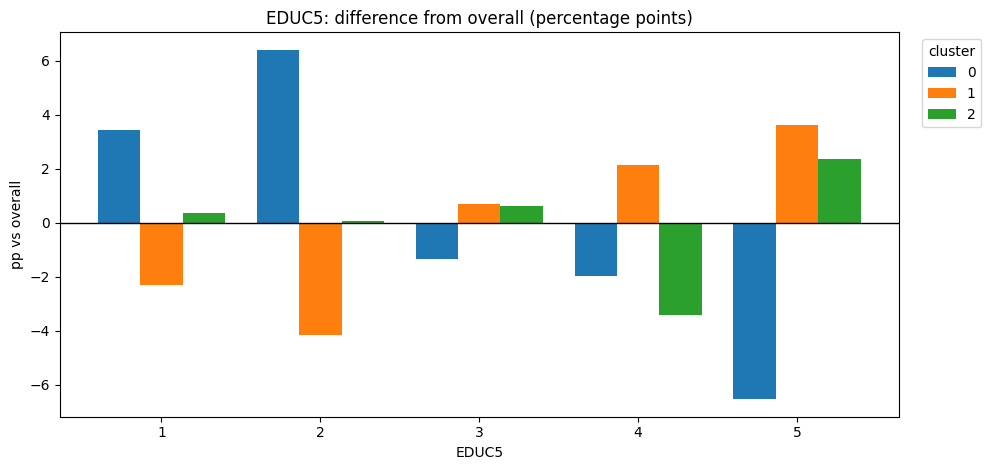

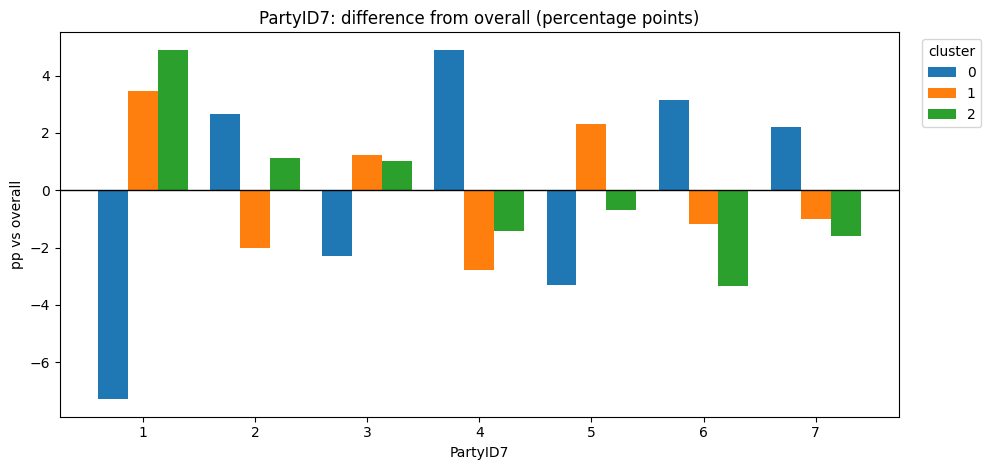

In [25]:
cluster_col = "cluster_concept"
wcol = "WEIGHT_GP"

rows = []
for v in DEMO_VARS:
    d = meta[[cluster_col, v, wcol]].dropna()
    if d.empty or d[v].nunique() < 2:
        continue
    tab = pd.crosstab(d[cluster_col], d[v], values=d[wcol], aggfunc="sum").fillna(0)
    if tab.shape[0] < 2 or tab.shape[1] < 2:
        continue
    chi2, pval, dof, _ = chi2_contingency(tab)
    n = tab.to_numpy().sum()
    r, c = tab.shape
    vcr = np.sqrt((chi2 / n) / max(min(r - 1, c - 1), 1))
    rows.append({"var": v, "chi2": chi2, "df": dof, "p_value": pval, "cramers_v": vcr})

demo_screen = pd.DataFrame(rows).sort_values("p_value") if rows else pd.DataFrame(columns=["var","chi2","df","p_value","cramers_v"])
if not demo_screen.empty:
    demo_screen["p_fdr_bh"] = multipletests(demo_screen["p_value"], method="fdr_bh")[1]
else:
    demo_screen["p_fdr_bh"] = []

demo_sig = demo_screen.loc[demo_screen["p_fdr_bh"] < 0.05, "var"].tolist() if not demo_screen.empty else []

heard = pd.to_numeric(meta["HeardOf"], errors="coerce")
heard_yes = heard.eq(1).astype(float).fillna(0.0)

Xc = X[CONCEPT_COLS].apply(pd.to_numeric, errors="coerce")
Xc = Xc.apply(lambda s: s.fillna(s.median()))
Xc_q = Xc.add_prefix("q__")

int_block = pd.DataFrame(
    {f"ix__{c}": heard_yes.values * Xc[c].values for c in CONCEPT_COLS},
    index=meta.index,
)

X_full = pd.concat([heard_yes.rename("Heard_yes"), Xc_q, int_block], axis=1).astype(float)
X_full = sm.add_constant(X_full, has_constant="add")
y_demo = meta[cluster_col].astype(int)

pred_mn = np.repeat(int(meta[cluster_col].mode().iloc[0]), len(meta))
for k in range(K_CHOSEN):
    meta[f"propensity_cluster_mnlogit_{k}"] = 0.0

full_fit = None
try:
    full_fit = sm.MNLogit(y_demo, X_full).fit(method="lbfgs", maxiter=2000, disp=False)
except Exception as ex:
    print("Full MNLogit (HeardOf + concepts + interactions) failed:", ex)

kept_ix = []
if full_fit is not None:
    pv = full_fit.pvalues
    int_names = [c for c in X_full.columns if str(c).startswith("ix__")]
    for col in int_names:
        if col not in pv.columns:
            continue
        if float(np.nanmin(pv[col].astype(float).values)) < INTERACTION_ALPHA:
            kept_ix.append(col)
    print(f"Interactions kept: {len(kept_ix)} / {len(int_names)} (p < {INTERACTION_ALPHA}, min p across outcome equations)")
    if kept_ix:
        display(pd.Series(kept_ix, name="kept_interaction_terms"))

base_cols = ["const", "Heard_yes"] + [f"q__{c}" for c in CONCEPT_COLS]
base_cols = [c for c in base_cols if c in X_full.columns]
use_cols = base_cols + [c for c in kept_ix if c in X_full.columns]
X_red = X_full[use_cols].copy()

try:
    red_fit = sm.MNLogit(y_demo, X_red).fit(method="lbfgs", maxiter=2000, disp=False)
    p_hat = np.asarray(red_fit.predict(X_red), dtype=float)
    pred_mn = p_hat.argmax(axis=1)
    for k in range(min(K_CHOSEN, p_hat.shape[1])):
        meta[f"propensity_cluster_mnlogit_{k}"] = p_hat[:, k]
except Exception as ex:
    print("Reduced MNLogit failed:", ex)

meta = meta.copy()
meta["pred_cluster_mnlogit"] = pred_mn.astype(int)

print("Demographic screen")
display(demo_screen)
print("Selected demographics (screening only):", demo_sig)
print("MNLogit in-sample accuracy (HeardOf + concepts + selected interactions):", round(float((meta["pred_cluster_mnlogit"] == meta[cluster_col]).mean()), 3))

vars_model = demo_sig[:10]
vars_plot = demo_sig[:6] if len(demo_sig) > 0 else vars_model[:6]

for v in vars_plot:
    d = meta[[cluster_col, v, wcol]].dropna().copy()
    if d.empty or d[v].nunique() <= 1:
        continue

    overall = d.groupby(v)[wcol].sum()
    overall = overall / overall.sum()

    tab = d.pivot_table(values=wcol, index=cluster_col, columns=v, aggfunc="sum", fill_value=0.0)
    tab = tab.div(tab.sum(axis=1), axis=0)

    pp = (tab - overall).fillna(0.0) * 100.0
    pp = pp.sort_index()

    cats = [str(c) for c in pp.columns]
    x = np.arange(len(cats))
    clus = pp.index.tolist()
    width = 0.8 / max(len(clus), 1)

    plt.figure(figsize=(10, 4.8))
    for i, cl in enumerate(clus):
        plt.bar(
            x + (i - (len(clus) - 1) / 2) * width,
            pp.loc[cl].values,
            width=width,
            label=str(cl),
        )

    plt.axhline(0, color="black", linewidth=1)
    plt.xticks(x, cats)
    plt.xlabel(v)
    plt.ylabel("pp vs overall")
    plt.title(f"{v}: difference from overall (percentage points)")
    plt.legend(title="cluster", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

## Step 4: Concept Item Differentiation Across Clusters
This step tests each concept question across clusters and ranks items by how strongly they differentiate groups.

In [26]:
item_rows = []
for c in CONCEPT_COLS:
    d = pd.DataFrame({"cluster": meta["cluster_concept"], "x": pd.to_numeric(X[c], errors="coerce")}).dropna()
    if d.empty or d["x"].nunique() < 2:
        continue
    tab = pd.crosstab(d["cluster"], d["x"])
    if tab.shape[0] < 2 or tab.shape[1] < 2:
        continue
    chi2, pval, dof, _ = chi2_contingency(tab)
    n = tab.to_numpy().sum()
    r, cc = tab.shape
    vcr = np.sqrt((chi2 / n) / max(min(r - 1, cc - 1), 1))
    item_rows.append({"item": c, "chi2": chi2, "df": dof, "p_value": pval, "cramers_v": vcr})

item_tests = pd.DataFrame(item_rows).sort_values("p_value") if item_rows else pd.DataFrame(columns=["item","chi2","df","p_value","cramers_v"])
if not item_tests.empty:
    item_tests["p_fdr_bh"] = multipletests(item_tests["p_value"], method="fdr_bh")[1]
else:
    item_tests["p_fdr_bh"] = []

print("Concept-item cluster differentiation ranking")
display(item_tests)

Concept-item cluster differentiation ranking


,item,chi2,df,p_value,cramers_v,p_fdr_bh
14,AccessToLawyers,544.775052,8,1.721087e-112,0.534342,6.195912e-111
18,FairProcedures,500.371369,8,5.855876e-103,0.511032,1.054058e-101
2,Enforce,481.357279,8,7.017476e-99,0.502278,8.420971e-98
3,EveryoneObey,480.518959,8,1.061594e-98,0.503427,9.554342e-98
30,TreatsEqual,476.789260,8,6.694876e-98,0.499890,4.820311e-97
13,RightsOfAccused,467.233475,8,7.490133e-96,0.494079,4.494080e-95
0,NoOneAbove,459.334239,8,3.695453e-94,0.490397,1.900519e-93
16,AccessToCourts,451.193119,8,2.052547e-92,0.485777,9.236464e-92
27,HumanRights,445.880893,8,2.821413e-91,0.482657,1.128565e-90
32,TrustAuthorities,433.139202,8,1.512476e-88,0.475462,5.444912e-88


## Step 5: Model diagnostics, cluster summaries, and predictions
This step prints feature-selection counts, full and reduced MNLogit summaries from Step 3, a coefficient table (by p-value), then builds rol_pc1 and reports confusion matrix, per-cluster accuracy, and rol_pc1 plots using `pred_cluster_mnlogit`.

Feature selection and MNLogit summary (objects from Step 3)


,item,count
0,design columns (full),74
1,main effects (Heard_yes + const + concepts),38
2,interaction terms Heard_yes x item (full),36
3,interaction terms kept after p < INTERACTION_A...,0
4,interaction terms dropped,36
5,design columns (reduced),38


INTERACTION_ALPHA = 0.05


,dropped_interaction
0,ix__NoOneAbove
1,ix__Obey
2,ix__Enforce
3,ix__EveryoneObey
4,ix__WayToFix
5,ix__Prospective
6,ix__Clear
7,ix__Consistent
8,ix__Possible
9,ix__Stable


Full model summary (all mains + all interactions)
                          MNLogit Regression Results                          
Dep. Variable:        cluster_concept   No. Observations:                  962
Model:                        MNLogit   Df Residuals:                      814
Method:                           MLE   Df Model:                          146
Date:                Wed, 29 Apr 2026   Pseudo R-squ.:                  0.6805
Time:                        19:12:26   Log-Likelihood:                -295.72
converged:                      False   LL-Null:                       -925.63
Covariance Type:            nonrobust   LLR p-value:                1.775e-176
       cluster_concept=1       coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                      -39.6278      7.503     -5.281      0.000     -54.334     -24.922
Heard_yes                   16.4323    

...

,pred_0,pred_1,pred_2
true_0,250,44,15
true_1,38,487,1
true_2,26,5,96


Accuracy by cluster


,cluster_concept,accuracy,n
0,0,0.809061,309
1,1,0.925856,526
2,2,0.755906,127


rol_pc1 summary by cluster


,cluster_concept,n,rol_pc1_mean,rol_pc1_sd
0,0,309,-1.461877,1.861441
1,1,526,2.039132,1.709993
2,2,127,-4.888688,2.769102


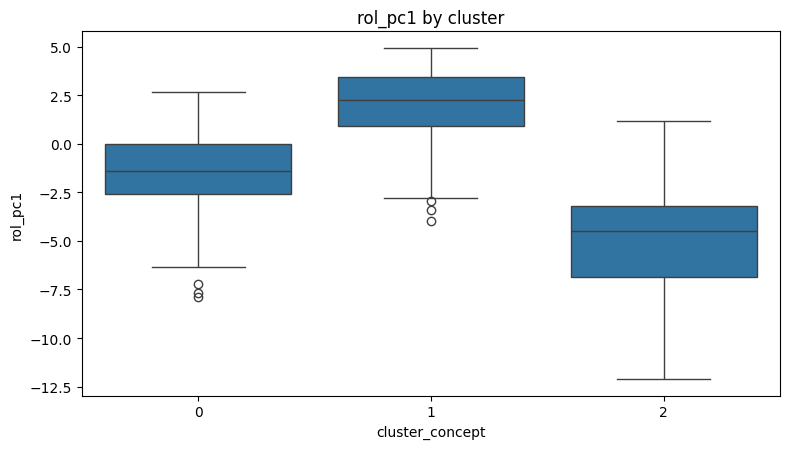

In [27]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

cluster_col = "cluster_concept"
pred_col = "pred_cluster_mnlogit"

g = globals()
full_fit = g.get("full_fit")
red_fit = g.get("red_fit")
X_full = g.get("X_full")
X_red = g.get("X_red")
kept_ix = g.get("kept_ix")

print("Feature selection and MNLogit summary (objects from Step 3)")
if X_full is not None:
    int_cols = [c for c in X_full.columns if str(c).startswith("ix__")]
    n_int_full = len(int_cols)
    kept_list = list(kept_ix) if kept_ix is not None else []
    n_int_kept = len(kept_list)
    dropped = [c for c in int_cols if c not in set(kept_list)]
    summ = pd.DataFrame(
        [
            {"item": "design columns (full)", "count": int(X_full.shape[1])},
            {"item": "main effects (Heard_yes + const + concepts)", "count": int(1 + 1 + len(CONCEPT_COLS))},
            {"item": "interaction terms Heard_yes x item (full)", "count": n_int_full},
            {"item": "interaction terms kept after p < INTERACTION_ALPHA", "count": n_int_kept},
            {"item": "interaction terms dropped", "count": len(dropped)},
            {"item": "design columns (reduced)", "count": int(X_red.shape[1]) if X_red is not None else None},
        ]
    )
    display(summ)
    print(f"INTERACTION_ALPHA = {INTERACTION_ALPHA}")
    if kept_list:
        display(pd.DataFrame({"kept_interaction": kept_list}))
    if dropped:
        display(pd.DataFrame({"dropped_interaction": dropped}))

if full_fit is not None:
    print("Full model summary (all mains + all interactions)")
    print(full_fit.summary())
else:
    print("full_fit not available (Step 3 full MNLogit may have failed).")

if red_fit is not None:
    print("Final reduced model summary")
    print(red_fit.summary())
    cp = red_fit.params.stack()
    pp = red_fit.pvalues.stack()
    tab = pd.DataFrame({"coef": cp, "pvalue": pp}).reset_index()
    tab.columns = ["outcome_eq", "param", "coef", "pvalue"]
    tab = tab.sort_values("pvalue")
    print("Reduced model: coefficients sorted by p-value (top 50 rows)")
    display(tab.head(50))
else:
    print("red_fit not available (Step 3 reduced MNLogit may have failed).")

X_imp = X.apply(lambda s: s.fillna(s.median()))
Z = StandardScaler().fit_transform(X_imp)
rol_pc1 = PCA(n_components=1, random_state=RANDOM_STATE).fit_transform(Z).ravel()
meta = meta.copy()
meta["rol_pc1"] = rol_pc1

if pred_col not in meta.columns:
    raise KeyError("Run Step 3 first; pred_cluster_mnlogit is created there.")

cm = confusion_matrix(meta[cluster_col].astype(int), meta[pred_col].astype(int), labels=sorted(meta[cluster_col].unique()))
cm_df = pd.DataFrame(cm, index=[f"true_{c}" for c in sorted(meta[cluster_col].unique())], columns=[f"pred_{c}" for c in sorted(meta[cluster_col].unique())])
print("Confusion matrix (vs Step 3 multinomial predictions)")
display(cm_df)

acc_rows = []
for c in sorted(meta[cluster_col].unique()):
    m = meta[cluster_col].astype(int).eq(int(c))
    acc = (meta.loc[m, pred_col].astype(int) == int(c)).mean()
    acc_rows.append({"cluster_concept": int(c), "accuracy": float(acc), "n": int(m.sum())})
acc_df = pd.DataFrame(acc_rows)
print("Accuracy by cluster")
display(acc_df)

summary_df = (
    meta.groupby(cluster_col)["rol_pc1"]
    .agg(n="count", rol_pc1_mean="mean", rol_pc1_sd="std")
    .reset_index()
    .sort_values(cluster_col)
)
print("rol_pc1 summary by cluster")
display(summary_df)

plt.figure(figsize=(8, 4.6))
sns.boxplot(data=meta, x=cluster_col, y="rol_pc1")
plt.title("rol_pc1 by cluster")
plt.tight_layout()
plt.show()

## Step 6: Cluster Distribution Plots
This step shows only the requested distribution views for each cluster without additional interpretation analysis.

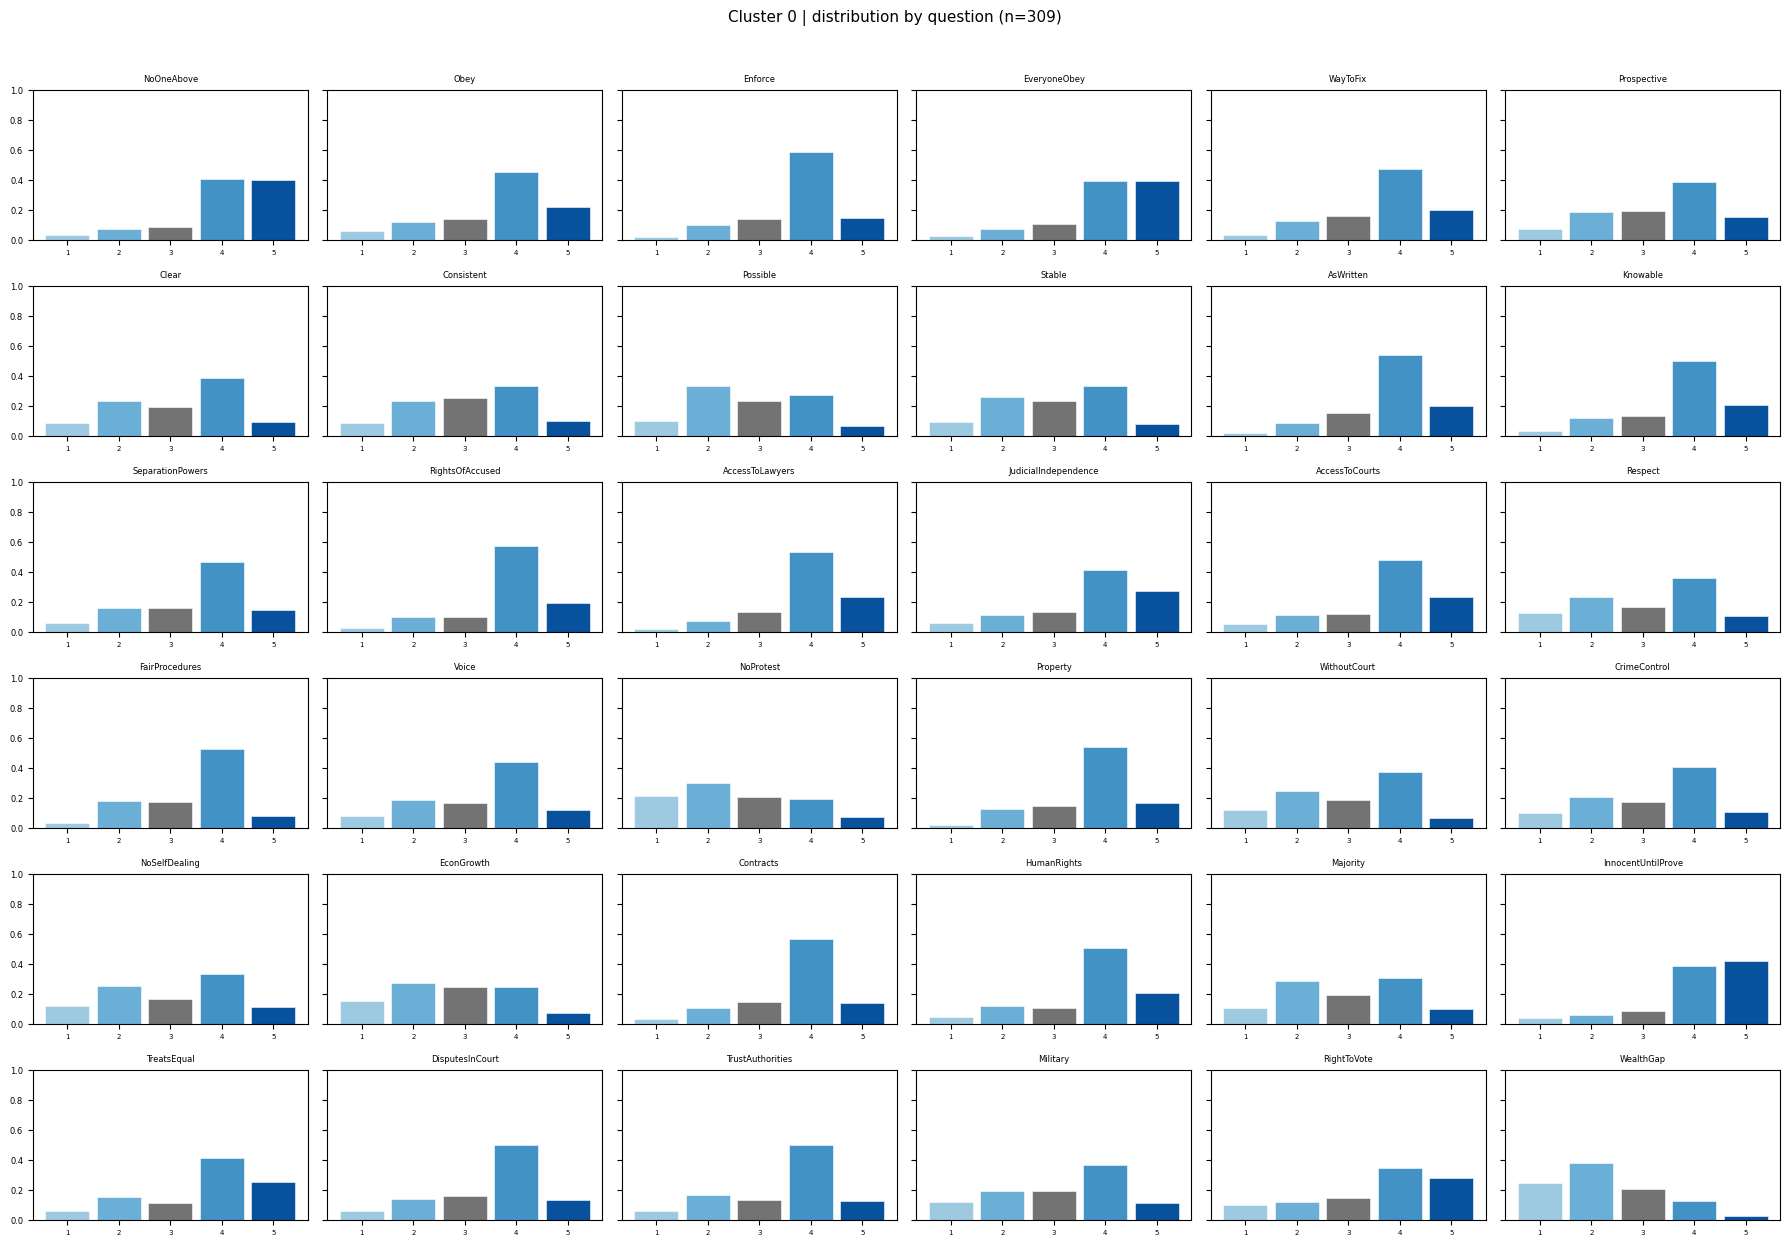

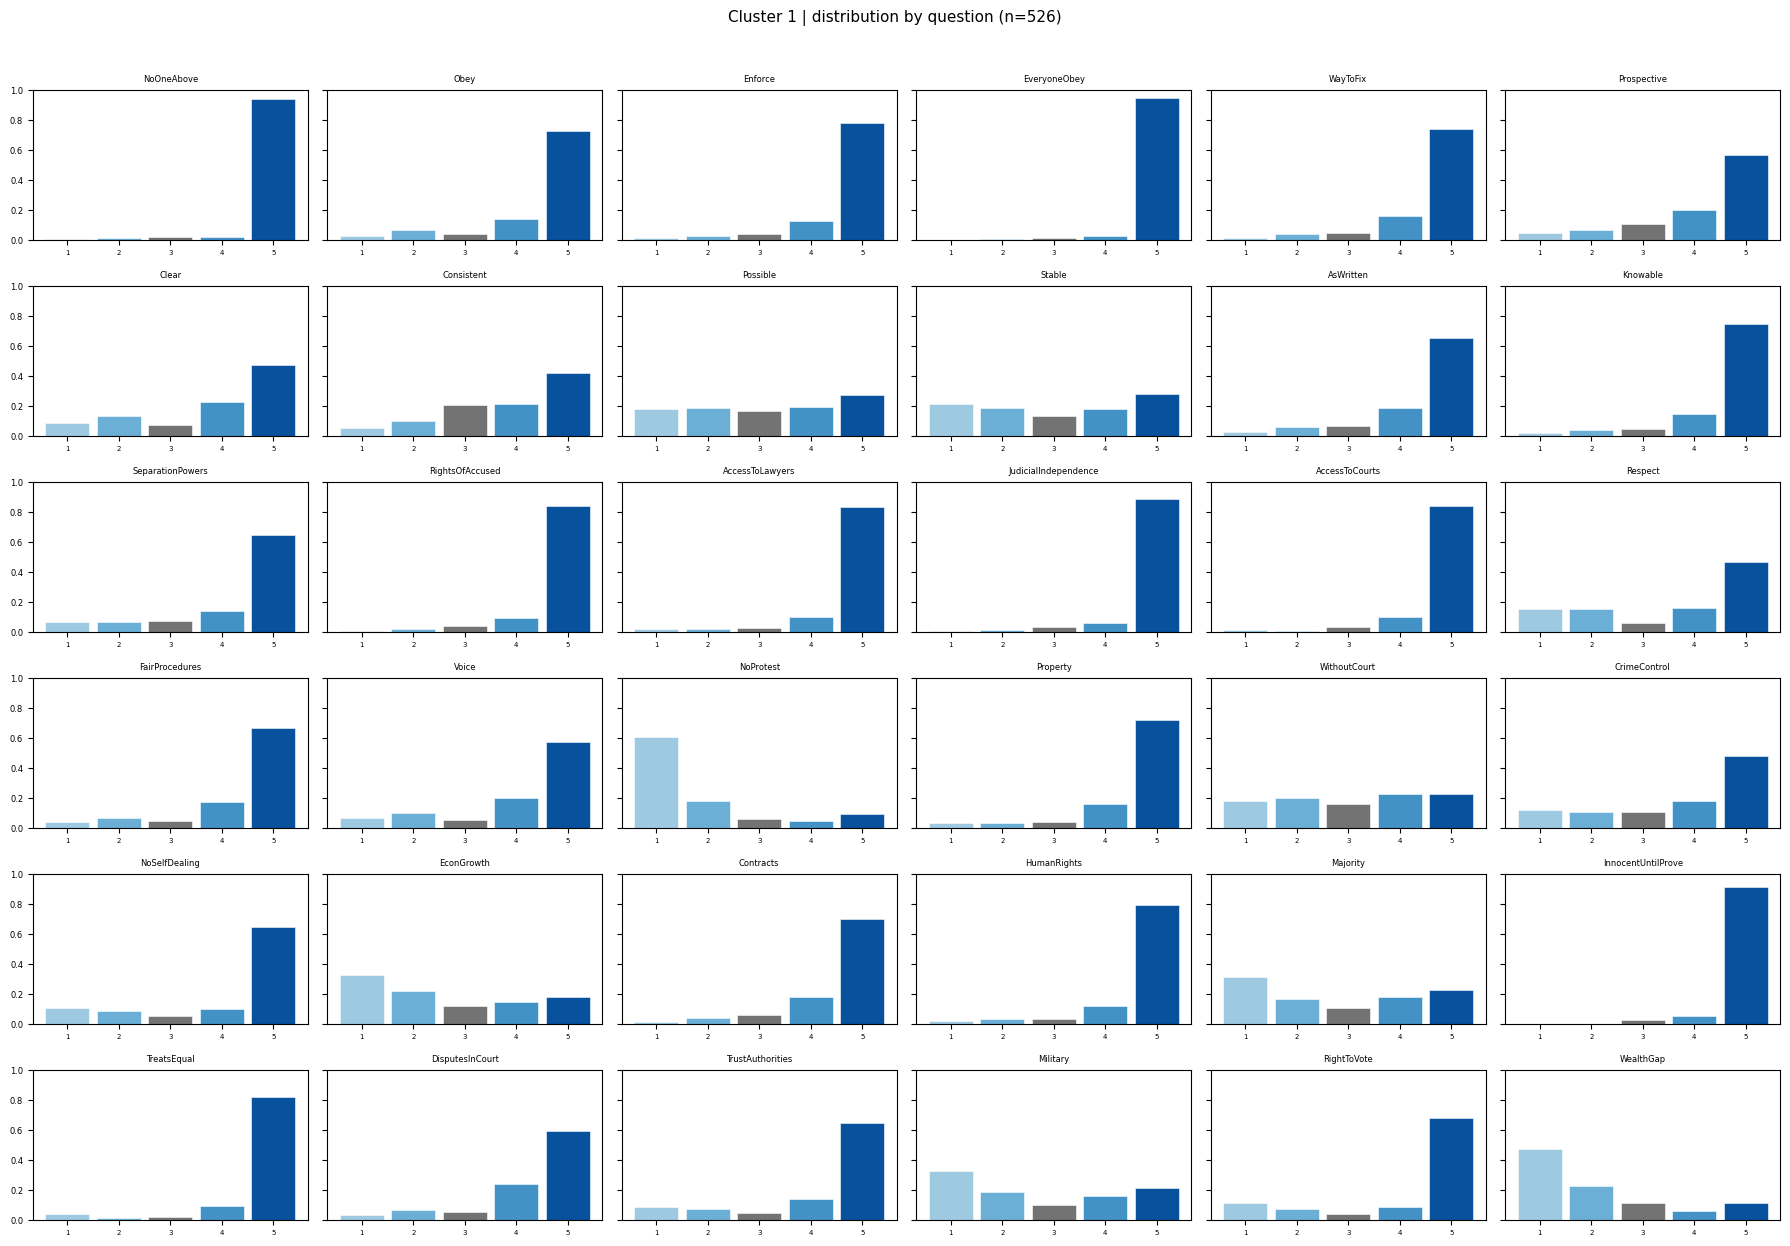

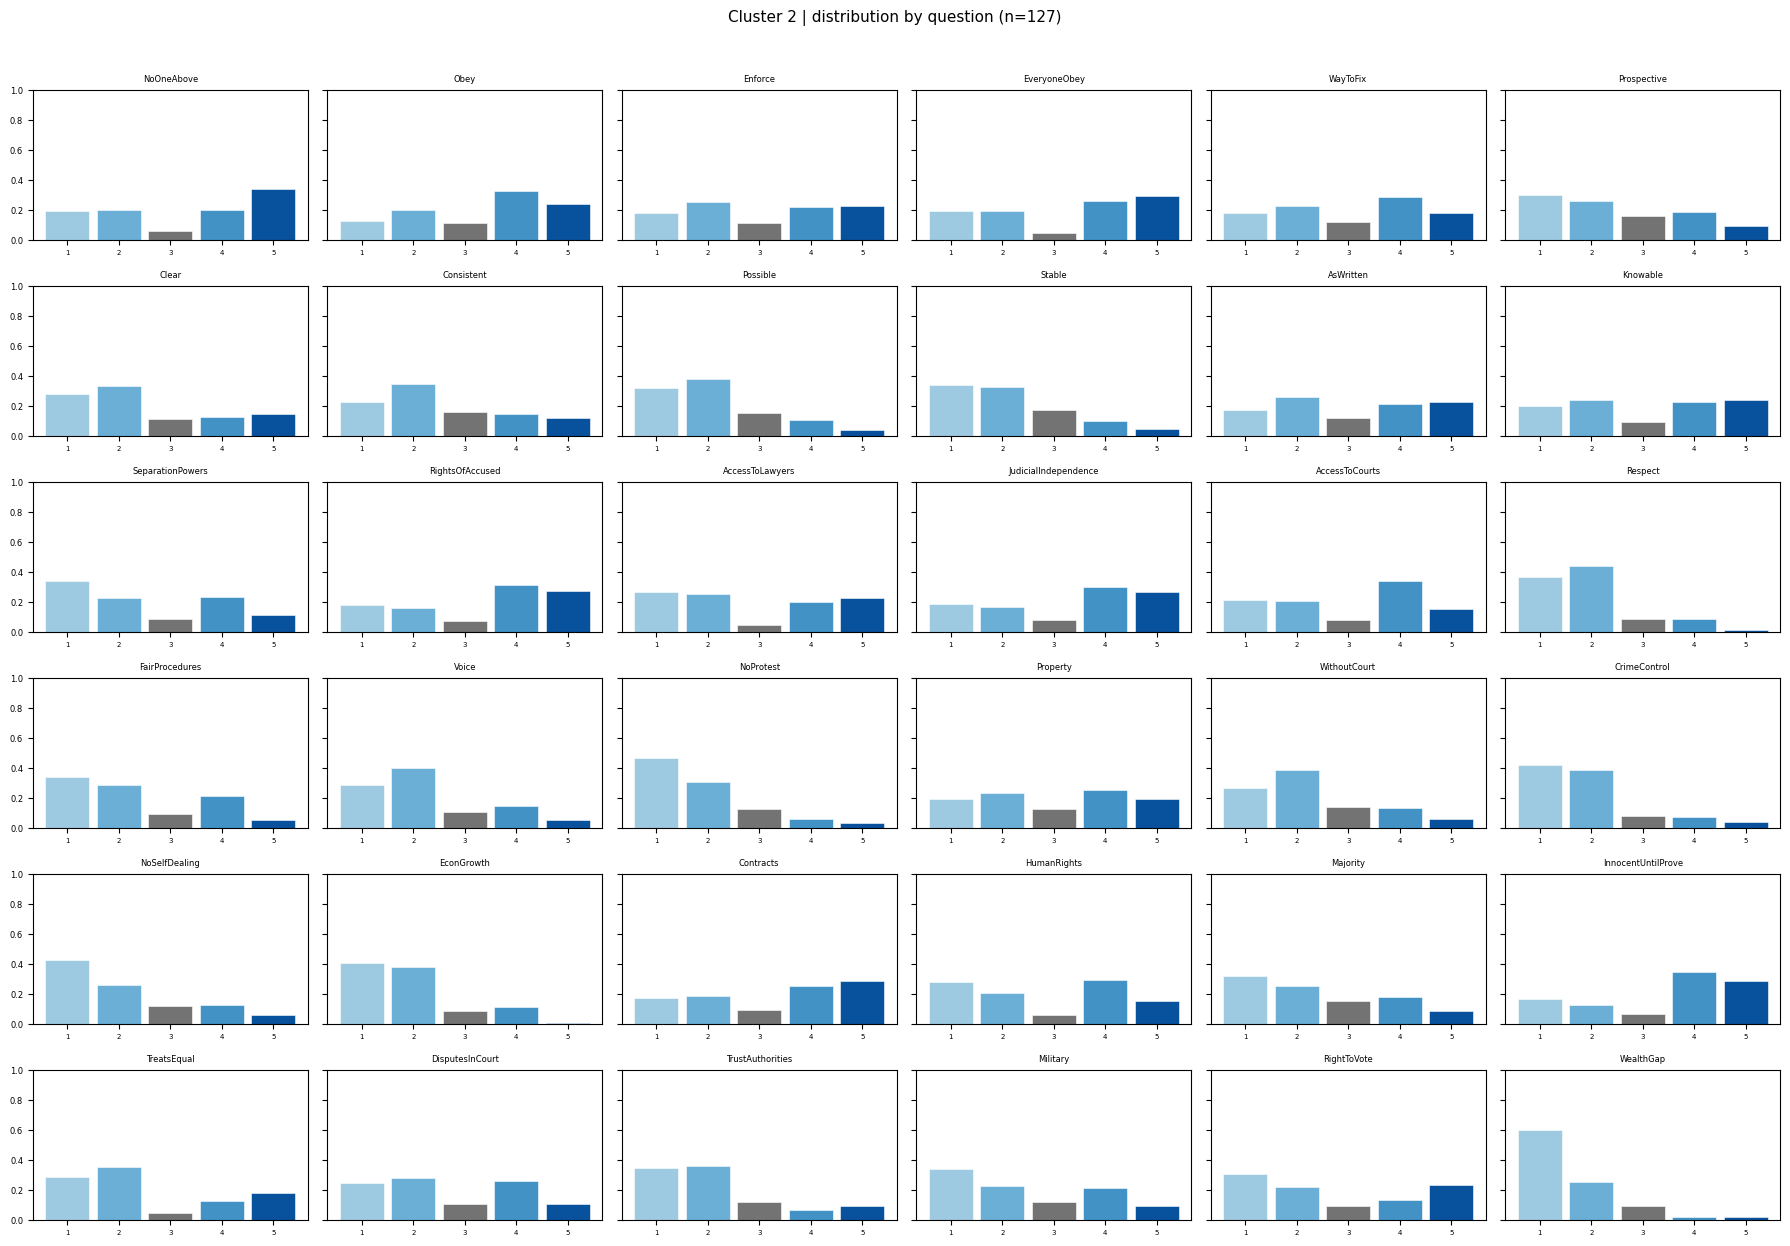

In [28]:
levels = [1, 2, 3, 4, 5]
clusters_sorted = sorted(meta["cluster_concept"].dropna().astype(int).unique().tolist())

for g in clusters_sorted:
    idx = meta.index[meta["cluster_concept"].astype(int).eq(g)]
    Xg = X.loc[idx, CONCEPT_COLS].apply(pd.to_numeric, errors="coerce")
    n_items = len(CONCEPT_COLS)
    n_cols = 6
    n_rows = int(np.ceil(n_items / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.0 * n_cols, 2.1 * n_rows), sharey=True)
    axes = np.array(axes).reshape(-1)

    for j, c in enumerate(CONCEPT_COLS):
        ax = axes[j]
        s = Xg[c]
        cnt = s.value_counts(dropna=True)
        total = float(cnt.sum())
        vals = np.array([cnt.get(k, 0.0) / total if total > 0 else 0.0 for k in levels])
        colors = ["#9ecae1", "#6baed6", "#737373", "#4292c6", "#08519c"]
        ax.bar(levels, vals, color=colors, width=0.85, edgecolor="white", linewidth=0.4)
        ax.set_xticks(levels)
        ax.set_ylim(0, 1)
        ax.set_title(c, fontsize=6)
        ax.tick_params(axis="x", labelsize=5)
        ax.tick_params(axis="y", labelsize=6)

    for j in range(n_items, len(axes)):
        axes[j].axis("off")

    fig.suptitle(f"Cluster {g} | distribution by question (n={len(idx)})", y=0.995, fontsize=11)
    plt.tight_layout(rect=(0, 0.01, 1, 0.98))
    plt.show()